In [7]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [9]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

In [10]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [11]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

EthanolConcentration 240
best result 34.60076045627377


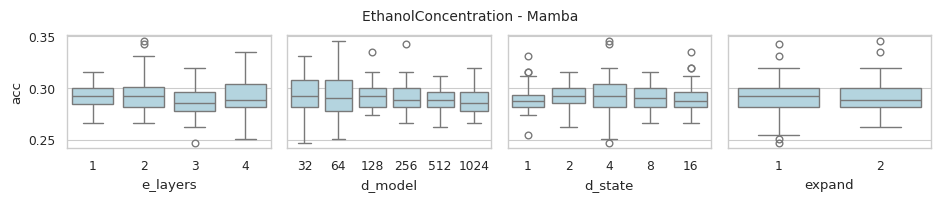

FaceDetection 240
best result 69.8921679909194


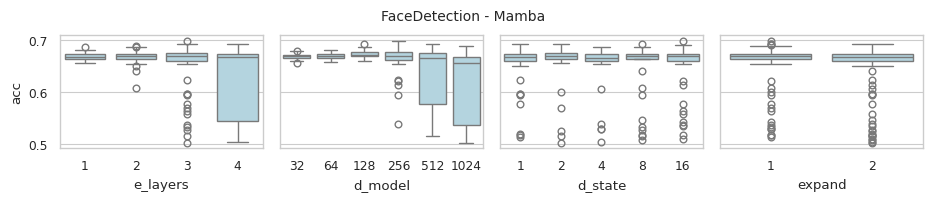

Handwriting 240
best result 36.58823529411765


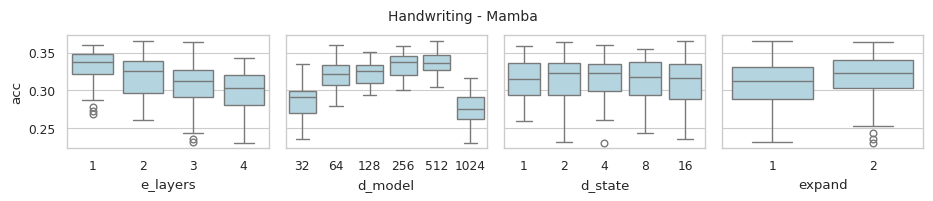

Heartbeat 240
best result 80.97560975609757


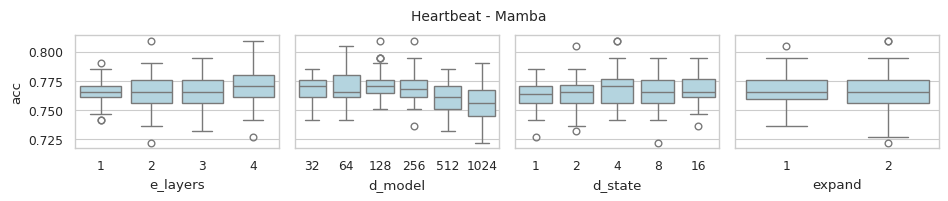

JapaneseVowels 240
best result 98.37837837837839


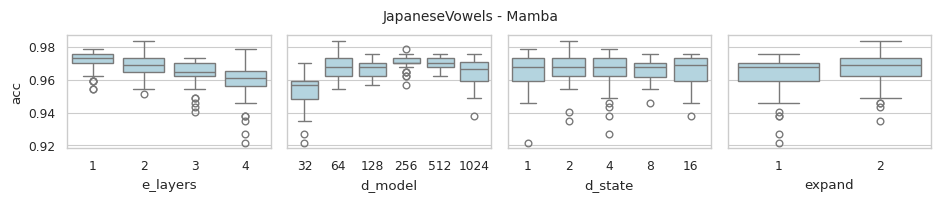

PEMS-SF 240
best result 90.17341040462428


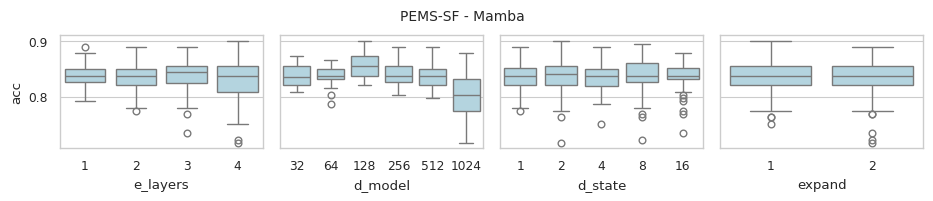

SelfRegulationSCP1 240
best result 92.83276450511946


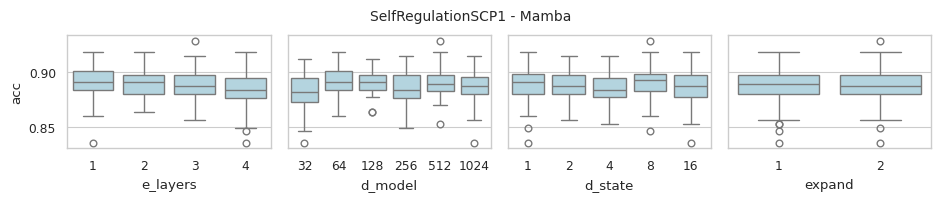

SelfRegulationSCP2 240
best result 60.0


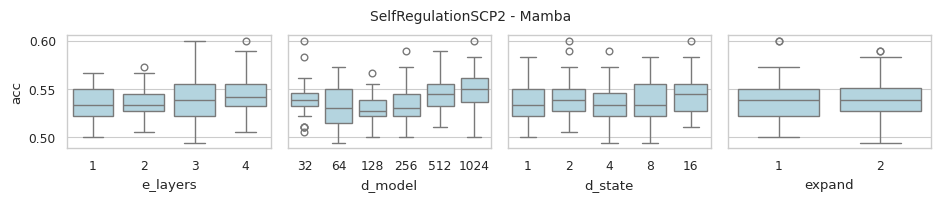

SpokenArabicDigits 240
best result 99.6361982719418


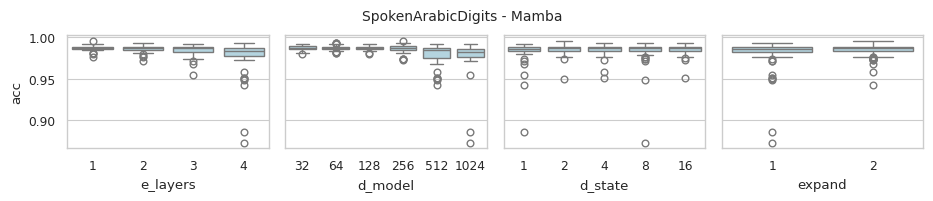

UWaveGestureLibrary 240
best result 88.75


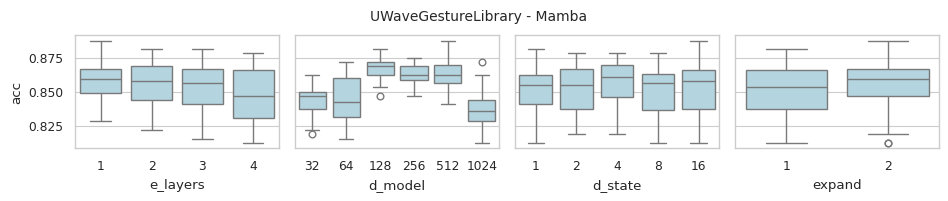

ArticularyWordRecognition 240
best result 99.0


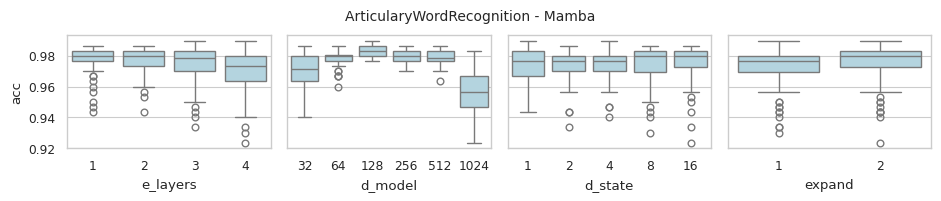

AtrialFibrillation 240
best result 66.66666666666666


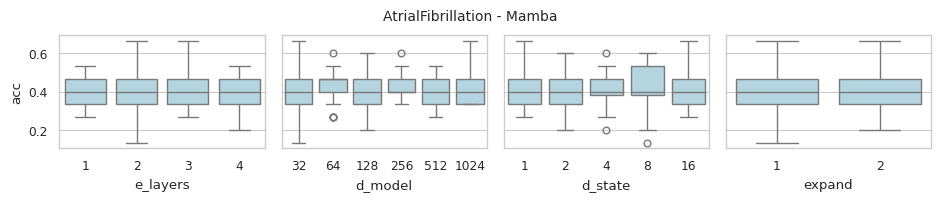

BasicMotions 240
best result 100.0


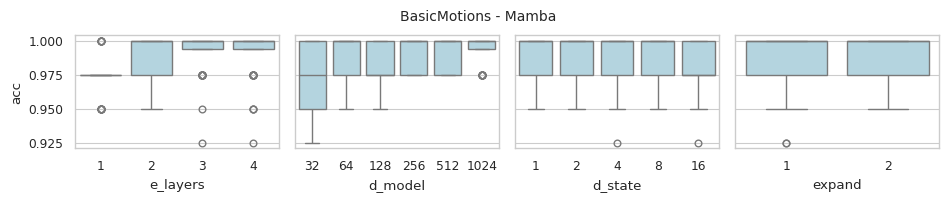

CharacterTrajectories 240
best result 98.81615598885793


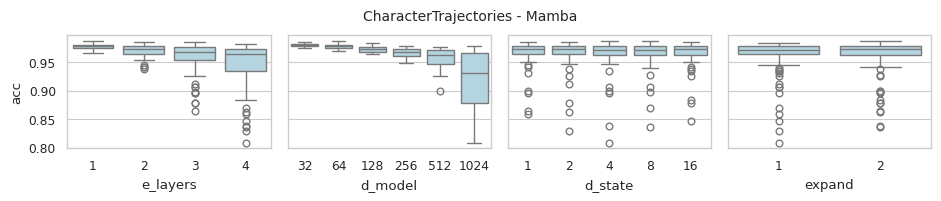

Cricket 240
best result 100.0


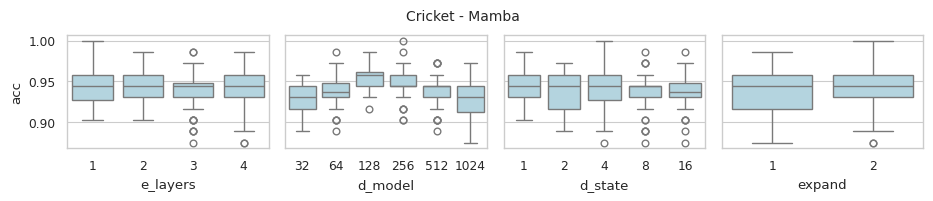

DuckDuckGeese 240
best result 66.0


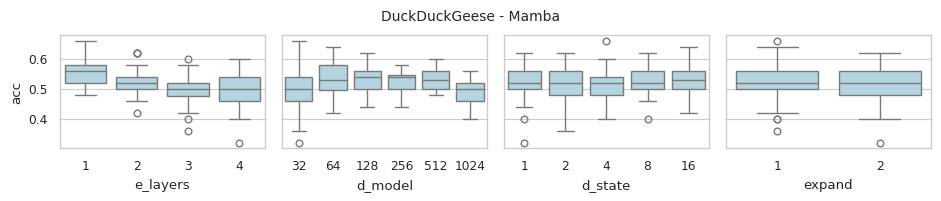

EigenWorms 225
best result 71.7557251908397


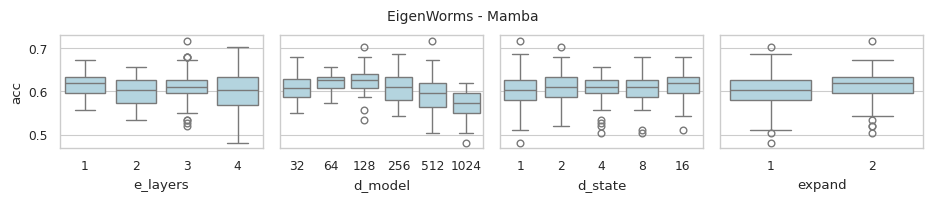

Epilepsy 240
best result 97.82608695652173


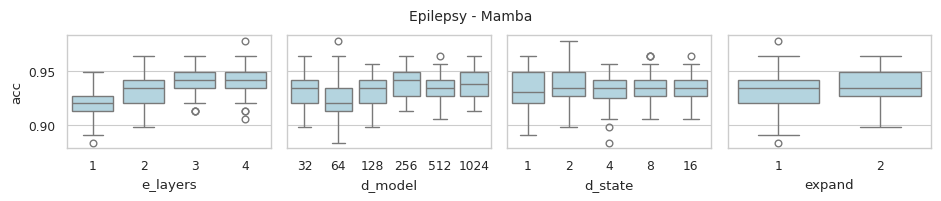

ERing 240
best result 96.29629629629629


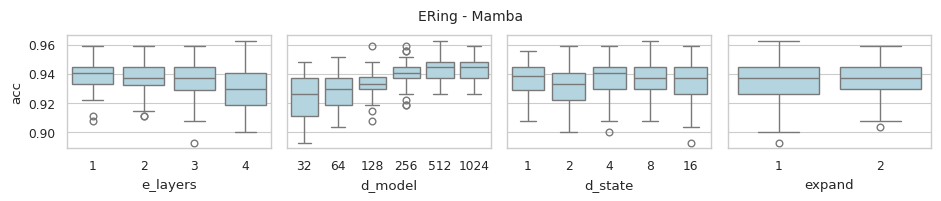

FingerMovements 240
best result 70.0


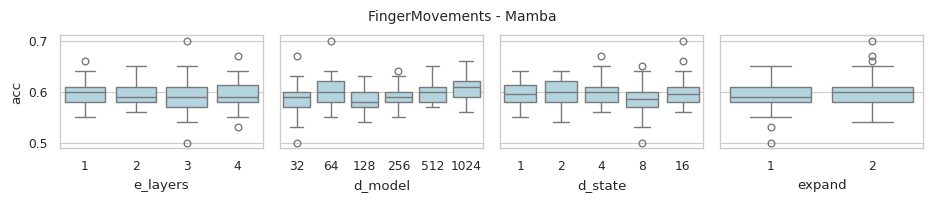

HandMovementDirection 240
best result 67.56756756756756


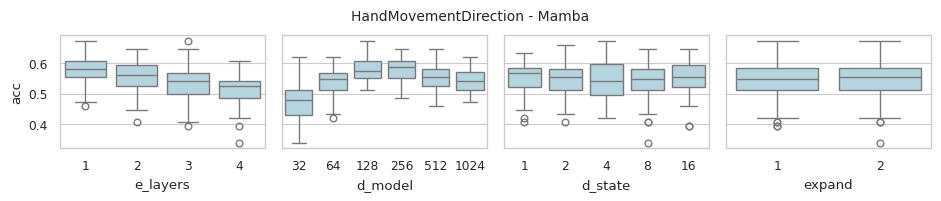

InsectWingbeat 240
best result 64.996


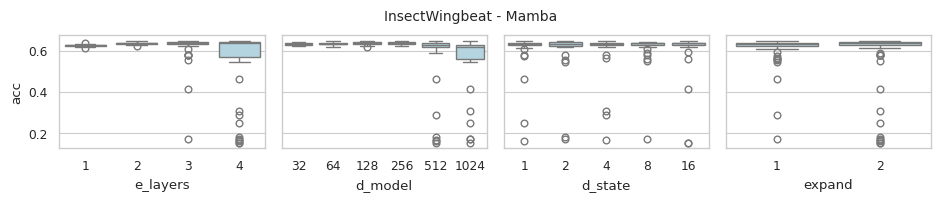

Libras 240
best result 85.55555555555556


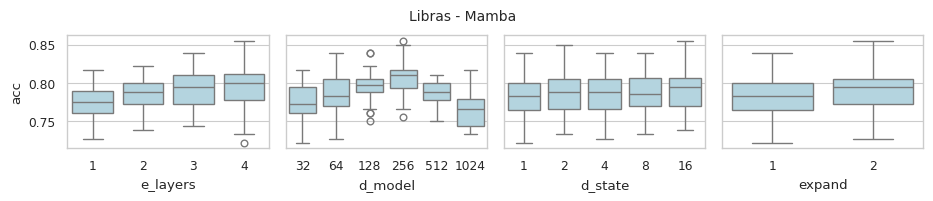

LSST 240
best result 43.63341443633414


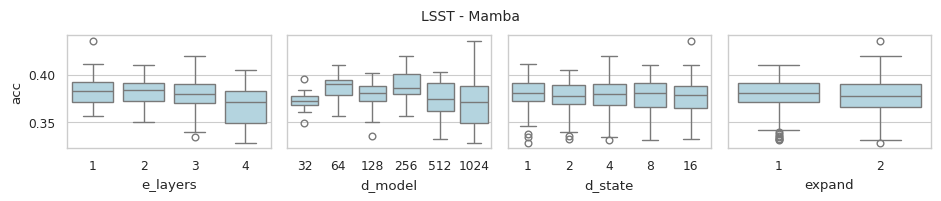

MotorImagery 240
best result 68.0


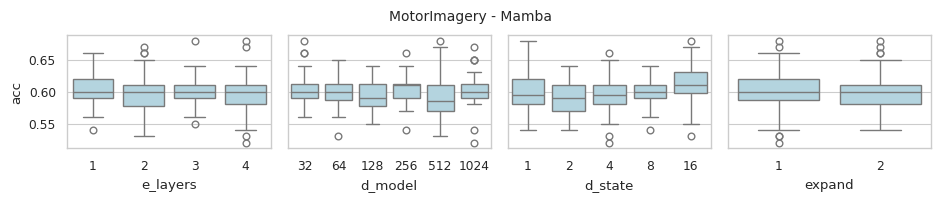

NATOPS 240
best result 97.77777777777777


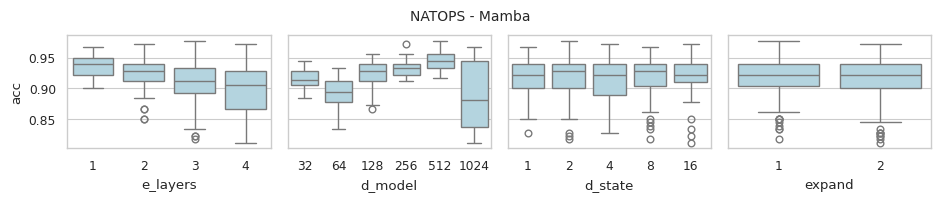

PenDigits 240
best result 98.9136649514008


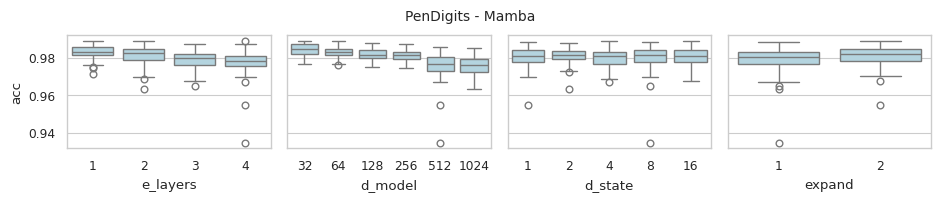

PhonemeSpectra 240
best result 13.987473903966595


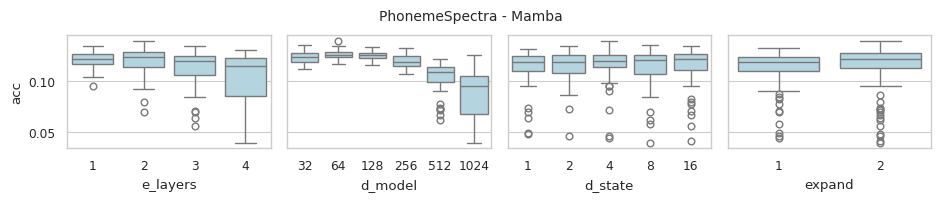

RacketSports 240
best result 92.10526315789474


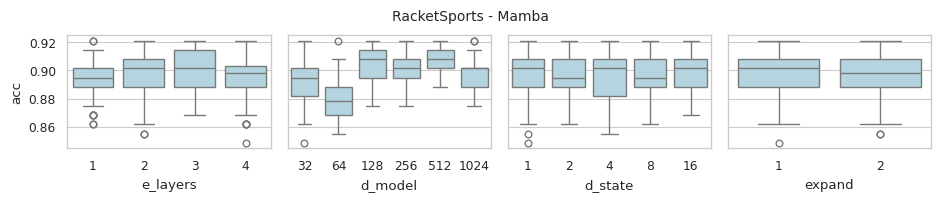

StandWalkJump 240
best result 73.33333333333333


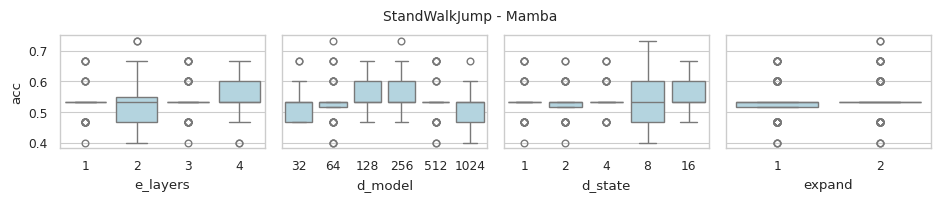

In [ ]:
model = 'Mamba'
result_dict = dict()

for data_name in UEA_MTSC30:
    try:
        with open(f'../03-full_results/{model} (additional)/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    except:
        continue
    
    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][17:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('el', ''))
            data_meta[10] = int(data_meta[10].replace('dm', ''))
            data_meta[11] = int(data_meta[11].replace('ds', ''))
            data_meta[12] = int(data_meta[12].replace('expand', ''))
            data_meta[13] = int(data_meta[13].replace('dc', ''))
            acc = float(data[i+2].replace('accuracy:', ''))
            model_params = data[i+3].replace('model parameter : ', '')
            model_size = data[i+4].replace('model size : ', '').replace('MB', '')


            result_data = {
                # 'task': data_meta[0],
                # 'model_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'e_layers': data_meta[9],
                'd_model': data_meta[10],
                'd_state': data_meta[11],
                'expand': data_meta[12],
                'd_conv': data_meta[13],
                'exp': data_meta[14],
                # 'desc': data_meta[15],
                'acc': acc,
                'model_params': int(model_params),
                'model_size (MB)': float(model_size),
                'ckpt': data[i].replace('>>>>>>>testing : ', '').replace('<', '')
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    print(data_name, len(result_df))
    print('best result', result_df['acc'].max()*100)

    cols = ['e_layers', 'd_model', 'd_state', 'expand']
    num_cols, num_rows = 4, 1

    # BOX PLOT
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(9.5, 2), sharey=True)
    for i, col in enumerate(cols):
        sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i], legend=False, color='lightblue')
        # # sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
        # sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i], legend=False, style='model', markers=True)
        # # minimum line
        # sns.lineplot(x=col, y='acc', data=result_df.groupby(col).min().reset_index(), ax=axs[i], legend=False, color='red', linestyle='--')
        # # maximum line
        # sns.lineplot(x=col, y='acc', data=result_df.groupby(col).max().reset_index(), ax=axs[i], legend=False, color='green', linestyle='--')
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

In [13]:
model_configs = {
    "e_layers" : [1, 2, 3, 4],
    "d_model" : [32, 64, 128, 256, 512, 1024],
    "d_ff" : [1, 2, 4, 8, 16],
    "expand" : [1, 2],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        e_layers = hyperparameter_combination['e_layers']
        d_model = hyperparameter_combination['d_model']
        d_ff = hyperparameter_combination['d_ff']
        expand = hyperparameter_combination['expand']

        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['d_model'] == d_model)
                & (tmp['d_state'] == d_ff)
                & (tmp['e_layers'] == e_layers)
                & (tmp['expand'] == expand)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



no acc for EigenWorms with {'e_layers': 2, 'd_model': 1024, 'd_ff': 1, 'expand': 2}
no acc for EigenWorms with {'e_layers': 2, 'd_model': 1024, 'd_ff': 2, 'expand': 2}
no acc for EigenWorms with {'e_layers': 2, 'd_model': 1024, 'd_ff': 4, 'expand': 2}
no acc for EigenWorms with {'e_layers': 2, 'd_model': 1024, 'd_ff': 8, 'expand': 2}
no acc for EigenWorms with {'e_layers': 2, 'd_model': 1024, 'd_ff': 16, 'expand': 2}
no acc for EigenWorms with {'e_layers': 3, 'd_model': 1024, 'd_ff': 1, 'expand': 2}
no acc for EigenWorms with {'e_layers': 3, 'd_model': 1024, 'd_ff': 2, 'expand': 2}
no acc for EigenWorms with {'e_layers': 3, 'd_model': 1024, 'd_ff': 4, 'expand': 2}
no acc for EigenWorms with {'e_layers': 3, 'd_model': 1024, 'd_ff': 8, 'expand': 2}
no acc for EigenWorms with {'e_layers': 3, 'd_model': 1024, 'd_ff': 16, 'expand': 2}
no acc for EigenWorms with {'e_layers': 4, 'd_model': 1024, 'd_ff': 1, 'expand': 2}
no acc for EigenWorms with {'e_layers': 4, 'd_model': 1024, 'd_ff': 2, 'ex

In [16]:
acc_all_df.loc[:,'max_1'] = acc_all_df.loc[:,[col for col in acc_all_df.columns if "'e_layers': 1" in col]].max(axis=1)
acc_all_df.loc[:,'max_2'] = acc_all_df.loc[:,[col for col in acc_all_df.columns if "'e_layers': 2" in col]].max(axis=1)
acc_all_df.loc[:,'max_3'] = acc_all_df.loc[:,[col for col in acc_all_df.columns if "'e_layers': 3" in col]].max(axis=1)
acc_all_df.loc[:,'max_4'] = acc_all_df.loc[:,[col for col in acc_all_df.columns if "'e_layers': 4" in col]].max(axis=1)
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,max_3,max_2,max_4,max_1,"{'e_layers': 3, 'd_model': 128, 'd_ff': 4, 'expand': 1}","{'e_layers': 2, 'd_model': 256, 'd_ff': 16, 'expand': 2}","{'e_layers': 2, 'd_model': 64, 'd_ff': 8, 'expand': 2}","{'e_layers': 1, 'd_model': 512, 'd_ff': 16, 'expand': 1}","{'e_layers': 3, 'd_model': 256, 'd_ff': 8, 'expand': 2}",...,"{'e_layers': 4, 'd_model': 1024, 'd_ff': 1, 'expand': 1}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 16, 'expand': 1}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 4, 'expand': 1}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 8, 'expand': 2}","{'e_layers': 3, 'd_model': 1024, 'd_ff': 8, 'expand': 1}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 8, 'expand': 1}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 4, 'expand': 2}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 1, 'expand': 2}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 16, 'expand': 2}","{'e_layers': 4, 'd_model': 1024, 'd_ff': 2, 'expand': 2}"
EthanolConcentration,0.34600760456274,0.31939163498099,0.34600760456274,0.33460076045627,0.31558935361217,0.2851711026616,0.2851711026616,0.3041825095057,0.2851711026616,0.2851711026616,...,0.2851711026616,0.31178707224335,0.27376425855513,0.2851711026616,0.2851711026616,0.26615969581749,0.27376425855513,0.27376425855513,0.28136882129278,0.28897338403042
FaceDetection,0.69892167990919,0.69892167990919,0.68757094211124,0.69239500567537,0.68728717366629,0.67253121452894,0.66032917139614,0.66515323496027,0.66458569807037,0.683314415437,...,0.51362088535755,0.54341657207718,0.52951191827469,0.50822928490352,0.53291713961407,0.66827468785471,0.50482406356413,0.51929625425653,0.50964812712826,0.52440408626561
Handwriting,0.36588235294118,0.36352941176471,0.36588235294118,0.34235294117647,0.36,0.30941176470588,0.35882352941176,0.32117647058824,0.35764705882353,0.34235294117647,...,0.26,0.25176470588235,0.29882352941176,0.24352941176471,0.28705882352941,0.25647058823529,0.23058823529412,0.27529411764706,0.25294117647059,0.26235294117647
Heartbeat,0.80975609756098,0.79512195121951,0.80975609756098,0.80975609756098,0.79024390243902,0.78536585365854,0.76585365853659,0.78048780487805,0.75609756097561,0.77560975609756,...,0.74634146341463,0.74634146341463,0.75609756097561,0.74146341463415,0.74634146341463,0.77073170731707,0.74146341463415,0.72682926829268,0.75609756097561,0.74146341463415
JapaneseVowels,0.98378378378378,0.97297297297297,0.98378378378378,0.97837837837838,0.97837837837838,0.96216216216216,0.97027027027027,0.97567567567568,0.97297297297297,0.97027027027027,...,0.95405405405405,0.95945945945946,0.93783783783784,0.96216216216216,0.97027027027027,0.95405405405405,0.95135135135135,0.94864864864865,0.95675675675676,0.95945945945946
PEMS-SF,0.90173410404624,0.89017341040462,0.89017341040462,0.90173410404624,0.89017341040462,0.86705202312139,0.83815028901734,0.84393063583815,0.84971098265896,0.86127167630058,...,0.77456647398844,0.77456647398844,0.7514450867052,0.72254335260116,0.80924855491329,0.76300578034682,0.80924855491329,0.78034682080925,0.76878612716763,0.71676300578035
SelfRegulationSCP1,0.92832764505119,0.92832764505119,0.91808873720137,0.91808873720137,0.91808873720137,0.90102389078498,0.89419795221843,0.89761092150171,0.89078498293515,0.87713310580205,...,0.91126279863481,0.87713310580205,0.88737201365188,0.86006825938567,0.88737201365188,0.89078498293515,0.88737201365188,0.89419795221843,0.91467576791809,0.89419795221843
SelfRegulationSCP2,0.6,0.6,0.57222222222222,0.6,0.56666666666667,0.56666666666667,0.54444444444444,0.51111111111111,0.51111111111111,0.52777777777778,...,0.57222222222222,0.55,0.55555555555556,0.56666666666667,0.5,0.53888888888889,0.56111111111111,0.55,0.56666666666667,0.55
SpokenArabicDigits,0.99636198271942,0.99226921327876,0.99317871759891,0.99317871759891,0.99636198271942,0.99135970895862,0.98726693951796,0.98544793087767,0.98681218735789,0.98271941791724,...,0.88585720782174,0.98362892223738,0.98362892223738,0.97953615279673,0.98362892223738,0.8731241473397,0.97771714415643,0.97953615279673,0.9731696

In [17]:
pd.set_option("display.precision", 14)
acc_all_df.loc[:,['max_1', 'max_2', 'max_3', 'max_4', 'max']]

,max_1,max_2,max_3,max_4,max
EthanolConcentration,0.31558935361217,0.34600760456274,0.31939163498099,0.33460076045627,0.34600760456274
FaceDetection,0.68728717366629,0.68757094211124,0.69892167990919,0.69239500567537,0.69892167990919
Handwriting,0.36,0.36588235294118,0.36352941176471,0.34235294117647,0.36588235294118
Heartbeat,0.79024390243902,0.80975609756098,0.79512195121951,0.80975609756098,0.80975609756098
JapaneseVowels,0.97837837837838,0.98378378378378,0.97297297297297,0.97837837837838,0.98378378378378
PEMS-SF,0.89017341040462,0.89017341040462,0.89017341040462,0.90173410404624,0.90173410404624
SelfRegulationSCP1,0.91808873720137,0.91808873720137,0.92832764505119,0.91808873720137,0.92832764505119
SelfRegulationSCP2,0.56666666666667,0.57222222222222,0.6,0.6,0.6
SpokenArabicDigits,0.99636198271942,0.99317871759891,0.99226921327876,0.99317871759891,0.99636198271942
UWaveGestureLibrary,0.8875,0.88125,0.88125,0.878125,0.8875


In [18]:
ranked_df = acc_all_df.loc[[idx for idx in acc_all_df.index if 'avg' not in idx],
                           ['max_1', 'max_2', 'max_3', 'max_4']].rank(ascending=False, method='min', axis=1)
print(f'AVG RANK: \n{ranked_df.mean(axis=0)}')
ranked_df

AVG RANK: 
max_1    2.43333333333333
max_2    2.06666666666667
max_3    1.90000000000000
max_4    2.10000000000000
dtype: float64


,max_1,max_2,max_3,max_4
EthanolConcentration,4.0,1.0,3.0,2.0
FaceDetection,4.0,3.0,1.0,2.0
Handwriting,3.0,1.0,2.0,4.0
Heartbeat,4.0,1.0,3.0,1.0
JapaneseVowels,2.0,1.0,4.0,2.0
PEMS-SF,2.0,2.0,2.0,1.0
SelfRegulationSCP1,2.0,2.0,1.0,2.0
SelfRegulationSCP2,4.0,3.0,1.0,1.0
SpokenArabicDigits,1.0,2.0,4.0,2.0
UWaveGestureLibrary,1.0,2.0,2.0,4.0
